# RepairWise Gemma — llama.cpp Local Demo
## Gemma 4 Good Hackathon · Special Technology Prize Track (llama.cpp)

Run RepairWise with **Gemma 4 E2B via llama.cpp** — the most resource-efficient
way to run Gemma 4 locally. A Q4_K_M quantized E2B model is ~1.5GB and runs on
any CPU with 4GB RAM.

This notebook demonstrates:
- Building llama.cpp with GGUF support
- Converting/downloading Gemma 4 E2B GGUF
- Running RepairWise multilingual assistant via llama.cpp server
- Streaming responses
- Multimodal photo analysis (llama.cpp with LLaVA-style vision)

### Why llama.cpp?
- **Smallest footprint**: Q4_K_M quantization = ~1.5GB vs 4GB+ for transformers
- **No Python GPU stack**: runs on CPU, Apple Silicon Metal, CUDA, Vulkan
- **Raspberry Pi compatible**: true edge deployment
- **OpenAI-compatible API**: drop-in replacement


## 1. Install llama.cpp

In [1]:
import subprocess, sys, os

# Install pre-built llama-cpp-python with server
print("Installing llama-cpp-python...")
result = subprocess.run([
    sys.executable, "-m", "pip", "install", "-qqq",
    "llama-cpp-python[server]",
    "--extra-index-url", "https://abetlen.github.io/llama-cpp-python/whl/cpu"
], capture_output=True, text=True)
print(result.stdout[-300:] if result.stdout else "")

# Also install huggingface_hub for downloading GGUF
subprocess.run([sys.executable, "-m", "pip", "install", "-qqq", "huggingface_hub"], 
               capture_output=True)
print("✅ llama-cpp-python installed")


Installing llama-cpp-python...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 63.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 1.7 MB/s eta 0:00:00

✅ llama-cpp-python installed


## 2. Download Gemma 4 E2B GGUF

In [2]:
from huggingface_hub import hf_hub_download
import os
from kaggle_secrets import UserSecretsClient

# Load HF token from Kaggle Secrets (needed for gated Gemma models)
try:
    secrets = UserSecretsClient()
    HF_TOKEN = secrets.get_secret("HF_TOKEN")
    print("✅ HF_TOKEN loaded from Kaggle Secrets")
except Exception:
    HF_TOKEN = os.environ.get("HF_TOKEN", None)
    print(f"✅ HF_TOKEN: {'found' if HF_TOKEN else 'not set — will try without token'}")

os.makedirs("./models", exist_ok=True)

# bartowski/google_gemma-4-E2B-it-GGUF is PUBLIC — no token needed
# Filename confirmed from: https://huggingface.co/bartowski/google_gemma-4-E2B-it-GGUF
GGUF_REPOS = [
    # Q4_K_M = best quality/size balance (3.46 GB) — recommended
    ("bartowski/google_gemma-4-E2B-it-GGUF", "google_gemma-4-E2B-it-Q4_K_M.gguf"),
    # Q4_K_S = slightly smaller (3.38 GB)
    ("bartowski/google_gemma-4-E2B-it-GGUF", "google_gemma-4-E2B-it-Q4_K_S.gguf"),
    # IQ4_XS = smallest 4-bit option (3.32 GB)
    ("bartowski/google_gemma-4-E2B-it-GGUF", "google_gemma-4-E2B-it-IQ4_XS.gguf"),
]

model_path = None
for repo_id, filename in GGUF_REPOS:
    try:
        print(f"Downloading {repo_id}/{filename}...")
        print("(3.4GB — takes 3-5 minutes on Kaggle)")
        model_path = hf_hub_download(
            repo_id=repo_id,
            filename=filename,
            local_dir="./models",
            token=HF_TOKEN,
        )
        size_gb = os.path.getsize(model_path) / 1e9
        print(f"✅ Downloaded: {model_path}")
        print(f"   Size: {size_gb:.2f} GB")
        break
    except Exception as e:
        print(f"   Failed ({filename}): {str(e)[:100]}")
        continue

if model_path is None:
    print("❌ All downloads failed. Check internet access and HF_TOKEN.")
else:
    print(f"\n✅ Model ready at: {model_path}")


✅ HF_TOKEN: not set — will try without token
(3.4GB — takes 3-5 minutes on Kaggle)


google_gemma-4-E2B-it-Q4_K_M.gguf:   0%|          | 0.00/3.46G [00:00<?, ?B/s]

✅ Downloaded: models/google_gemma-4-E2B-it-Q4_K_M.gguf
   Size: 3.46 GB

✅ Model ready at: models/google_gemma-4-E2B-it-Q4_K_M.gguf


## 3. Start llama.cpp server

In [3]:
import subprocess, time, urllib.request, json, os

if not os.path.exists(model_path):
    print(f"⚠️  Model not found at {model_path}")
else:
    print(f"Starting llama.cpp server with {model_path}...")
    server_process = subprocess.Popen([
        "python", "-m", "llama_cpp.server",
        "--model", model_path,
        "--host", "0.0.0.0",
        "--port", "8080",
        "--n_ctx", "2048",
        "--n_threads", "4",
    ], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

    print("Waiting for server (~30s)...")
    time.sleep(30)

    # Try different health endpoints depending on llama-cpp-python version
    ENDPOINTS = [
        "http://localhost:8080/v1/models",
        "http://localhost:8080/health",
        "http://localhost:8080/",
    ]
    server_ok = False
    for endpoint in ENDPOINTS:
        try:
            resp = urllib.request.urlopen(endpoint, timeout=5)
            print(f"✅ llama.cpp server running — {endpoint} responded {resp.status}")
            server_ok = True
            break
        except urllib.error.HTTPError as e:
            if e.code in (200, 405):  # 405 = method not allowed but server is up
                print(f"✅ llama.cpp server running (code {e.code})")
                server_ok = True
                break
        except Exception:
            continue

    if not server_ok:
        print("⚠️  Server may still be loading the model (3.4GB takes time)")
        print("   Wait 30 more seconds then run the inference cells")
        time.sleep(30)
        print("   Continuing anyway...")


Starting llama.cpp server with models/google_gemma-4-E2B-it-Q4_K_M.gguf...
Waiting for server (~30s)...
✅ llama.cpp server running — http://localhost:8080/v1/models responded 200


## 4. RepairWise via llama.cpp

In [4]:
import urllib.request, json

LLAMACPP_URL = "http://localhost:8080"

SYSTEM_PROMPT = (
    "You are RepairWise Gemma, a professional phone repair technician and digital safety advisor. "
    "Help people understand phone problems and avoid SMS scams. "
    "Always respond in the SAME language as the user. "
    "Use EXACTLY this 5-section structure:\n"
    "1. Probable diagnosis:\n2. Risk level: HIGH 🔴 / MEDIUM 🟡 / LOW 🟢\n"
    "3. What to do right now:\n4. When to see a professional:\n5. Sources: [id]"
)

def repairwise_llamacpp(query: str, language: str = "Spanish") -> str:
    prompt = (
        f"<start_of_turn>user\n{SYSTEM_PROMPT}\n\n"
        f"Language: {language}\nQuery: {query}\n"
        f"<end_of_turn>\n<start_of_turn>model\n"
    )
    payload = json.dumps({
        "prompt": prompt,
        "max_tokens": 300,
        "temperature": 0.4,
        "frequency_penalty": 1.12,
        "stop": ["<end_of_turn>", "<start_of_turn>"],
        "stream": False,
    }).encode()
    req = urllib.request.Request(
        f"{LLAMACPP_URL}/v1/completions",
        data=payload,
        headers={"Content-Type": "application/json"},
        method="POST",
    )
    with urllib.request.urlopen(req, timeout=120) as resp:
        return json.loads(resp.read()).get("content","").replace("<end_of_turn>","").strip()

# Test cases
tests = [
    ("Me ha llegado un SMS del banco con un link y me pide la tarjeta.", "Spanish"),
    ("Mi batería está hinchada y la pantalla se levanta.", "Spanish"),
    ("I dropped my phone in water and now it is getting hot.", "English"),
    ("El meu mòbil no s'encén.", "Catalan"),
    ("Telefonul nu se încarcă.", "Romanian"),
    ("مجھے بینک کا پیغام آیا جس میں کارڈ مانگا گیا۔", "Urdu"),
]

print("=" * 65)
print("RepairWise Gemma — llama.cpp Backend")
print(f"Model: Gemma 4 E2B Q4_K_M | Size: ~1.5GB | CPU inference")
print("=" * 65)

for query, lang in tests:
    print(f"\n[{lang}] {query[:55]}...")
    try:
        ans = repairwise_llamacpp(query, lang)
        print(ans[:350])
    except Exception as e:
        print(f"Error: {e}")
    print("-" * 65)


RepairWise Gemma — llama.cpp Backend
Model: Gemma 4 E2B Q4_K_M | Size: ~1.5GB | CPU inference

[Spanish] Me ha llegado un SMS del banco con un link y me pide la...

-----------------------------------------------------------------

[Spanish] Mi batería está hinchada y la pantalla se levanta....

-----------------------------------------------------------------

[English] I dropped my phone in water and now it is getting hot....

-----------------------------------------------------------------

[Catalan] El meu mòbil no s'encén....

-----------------------------------------------------------------

[Romanian] Telefonul nu se încarcă....

-----------------------------------------------------------------

[Urdu] مجھے بینک کا پیغام آیا جس میں کارڈ مانگا گیا۔...

-----------------------------------------------------------------


## 5. Streaming demo

In [5]:
# Original streaming attempt — server returns empty content (known llama.cpp GGUF behavior)
# Use repairwise_llamacpp_stream_visual() instead

def repairwise_llamacpp_stream(query: str, language: str = "Spanish"):
    prompt = (
        f"<start_of_turn>user\n{SYSTEM_PROMPT}\n\n"
        f"Language: {language}\nQuery: {query}\n"
        f"<end_of_turn>\n<start_of_turn>model\n"
    )
    payload = json.dumps({
    "prompt": prompt, "max_tokens": 500, "temperature": 0.7,
    "stop": ["<end_of_turn>"],
    "stream": True,
}).encode()
    req = urllib.request.Request(
        f"{LLAMACPP_URL}/v1/completions", data=payload,
        headers={"Content-Type": "application/json"}, method="POST",
    )
    full = ""
    with urllib.request.urlopen(req, timeout=120) as resp:
        for line in resp:
            line = line.decode("utf-8").strip()
            if line.startswith("data: ") and line != "data: [DONE]":
                try:
                    chunk = json.loads(line[6:])
                    # llama.cpp uses choices[0]["text"] not "content"
                    tok = chunk.get("choices", [{}])[0].get("text", "")
                    if not tok:
                        tok = chunk.get("content", "")
                    print(tok, end="", flush=True)
                    full += tok
                    if chunk.get("choices", [{}])[0].get("finish_reason"):
                        break
                except Exception:
                    pass
    print()
    return full

print("Streaming — batería hinchada:")
print("-" * 65)
repairwise_llamacpp_stream("Mi batería está hinchada y la pantalla se levanta.", "Spanish")

Streaming — batería hinchada:
-----------------------------------------------------------------
1. Diagnóstico probable:
2. Nivel de riesgo: HIGH 🔴
3. Qué hacer ahora:
4. Cuándo ver a un profesional:
5. Fuentes: [id]


'1. Diagnóstico probable:\n2. Nivel de riesgo: HIGH 🔴\n3. Qué hacer ahora:\n4. Cuándo ver a un profesional:\n5. Fuentes: [id]'

In [6]:
# Visual streaming — uses non-streaming endpoint which works correctly with llama.cpp server

def repairwise_llamacpp_stream_visual(query: str, language: str = "Spanish"):
    """Visual streaming effect using non-streaming endpoint (which works correctly)."""
    import time
    
    # Get full response from working non-streaming endpoint
    response = repairwise_llamacpp(query, language)
    
    # Print character by character for visual streaming effect
    for char in response:
        print(char, end='', flush=True)
        time.sleep(0.008)
    print()
    return response

print("Streaming — batería hinchada:")
print("-" * 65)
repairwise_llamacpp_stream_visual(
    "Mi batería está hinchada y la pantalla se levanta.", "Spanish"
)

Streaming — batería hinchada:
-----------------------------------------------------------------



''

In [7]:
import urllib.request, json

LLAMACPP_URL = "http://localhost:8080"

SYSTEM = (
    "You are RepairWise Gemma, a phone repair and scam safety assistant. "
    "Respond in Spanish. Use: 1.Diagnosis 2.Risk HIGH/MEDIUM/LOW 3.Steps 4.Professional 5.Sources"
)

# Gemma 4 format for bartowski GGUF
prompt = (
    f"<bos><|turn>system\n{SYSTEM}<turn|>\n"
    f"<|turn>user\nMe ha llegado un SMS del banco con un link.<turn|>\n"
    f"<|turn>model\n"
)

payload = json.dumps({
    "prompt": prompt,
    "max_tokens": 300,
    "temperature": 0.4,
    "stop": ["<turn|>", "<|turn>"],
    "stream": False,
}).encode()

req = urllib.request.Request(
    f"{LLAMACPP_URL}/v1/completions",
    data=payload,
    headers={"Content-Type": "application/json"},
    method="POST",
)
with urllib.request.urlopen(req, timeout=120) as resp:
    data = json.loads(resp.read())
    print(repr(data["choices"][0]["text"][:200]))

'¡Hola! Entiendo que has recibido un SMS de tu banco con un enlace. **Esto suena como un intento de *phishing***, y es muy importante que tomes precauciones inmediatamente.\n\nAquí tienes mi análisis:\n\n*'


In [8]:
LLAMACPP_URL = "http://localhost:8080"

SYSTEM_PROMPT = (
    "You are RepairWise Gemma, a professional phone repair technician and digital safety advisor. "
    "Help people understand phone problems and avoid SMS scams. "
    "Always respond in the SAME language as the user. "
    "Use EXACTLY this 5-section structure:\n"
    "1. Probable diagnosis:\n2. Risk level: HIGH 🔴 / MEDIUM 🟡 / LOW 🟢\n"
    "3. What to do right now:\n4. When to see a professional:\n5. Sources: [id]"
)

def repairwise_llamacpp(query, language="Spanish"):
    prompt = (
        f"<bos><|turn>system\n{SYSTEM_PROMPT}<turn|>\n"
        f"<|turn>user\nLanguage: {language}\nQuery: {query}<turn|>\n"
        f"<|turn>model\n"
    )
    payload = json.dumps({
        "prompt": prompt,
        "max_tokens": 300,
        "temperature": 0.4,
        "stop": ["<turn|>", "<|turn>"],
        "stream": False,
    }).encode()
    req = urllib.request.Request(
        f"{LLAMACPP_URL}/v1/completions",
        data=payload,
        headers={"Content-Type": "application/json"},
        method="POST",
    )
    with urllib.request.urlopen(req, timeout=120) as resp:
        data = json.loads(resp.read())
        return data["choices"][0]["text"].replace("<turn|>","").strip()

tests = [
    ("Me ha llegado un SMS del banco con un link y me pide la tarjeta.", "Spanish"),
    ("Mi batería está hinchada y la pantalla se levanta.", "Spanish"),
    ("I dropped my phone in water and now it is getting hot.", "English"),
    ("El meu mòbil no s'encén.", "Catalan"),
    ("Telefonul nu se încarcă.", "Romanian"),
    ("مجھے بینک کا پیغام آیا جس میں کارڈ مانگا گیا۔", "Urdu"),
]

print("=" * 65)
print("RepairWise Gemma — llama.cpp Backend WORKING")
print(f"Model: google_gemma-4-E2B-it-Q4_K_M.gguf | 3.46GB | CPU")
print("=" * 65)

for query, lang in tests:
    print(f"\n[{lang}] {query[:55]}...")
    print("-" * 65)
    ans = repairwise_llamacpp(query, lang)
    print(ans[:400])

RepairWise Gemma — llama.cpp Backend WORKING
Model: google_gemma-4-E2B-it-Q4_K_M.gguf | 3.46GB | CPU

[Spanish] Me ha llegado un SMS del banco con un link y me pide la...
-----------------------------------------------------------------
1. Probable diagnosis:
Se trata de un intento de *phishing*. El mensaje que ha recibido es una táctica común utilizada por estafadores para robar sus credenciales bancarias. El enlace le dirige a una página falsa que imita al sitio web de su banco, y si introduce sus datos (como los de su tarjeta), estos serán robados.

2. Risk level: HIGH 🔴
El riesgo es muy alto porque el objetivo es el robo dire

[Spanish] Mi batería está hinchada y la pantalla se levanta....
-----------------------------------------------------------------
1. Probable diagnosis:
El síntoma de una batería hinchada y que hace que la pantalla se levante es un signo muy serio de un problema interno grave, generalmente relacionado con el sobrecalentamiento o un fallo interno de la batería

## 6. Architecture & resource comparison

```
Backend         | RAM    | GPU    | Speed  | Privacy | Setup
----------------|--------|--------|--------|---------|-------
Transformers HF | 8GB+   | ✅ req | Fast   | ✅ local| Complex
Ollama          | 8GB    | Optional| Medium| ✅ local| Easy
llama.cpp       | 4GB    | Optional| Medium| ✅ local| Medium
llama.cpp Q8    | 3GB    | Optional| Medium| ✅ local| Medium
llama.cpp Q4_KM | 1.5GB  | Optional| OK    | ✅ local| Medium
```

### Running on edge devices

```bash
# Raspberry Pi 5 (4GB RAM) — true edge deployment
llama-server --model gemma-4-e2b-q4_k_m.gguf --n-ctx 1024 --threads 4

# MacBook Air M2 (Metal acceleration)
llama-server --model gemma-4-e2b-q4_k_m.gguf --n-gpu-layers 35

# RepairWise with llama.cpp backend
REPAIRWISE_BACKEND=llamacpp LLAMACPP_URL=http://localhost:8080 python app.py
```

All data stays on-device. No internet required after model download.
No HuggingFace token. No Python GPU stack. No CUDA.


## ✅ Local deployment — tested on consumer hardware

RepairWise was tested locally on a standard consumer PC **without GPU**:

| Component | Spec |
|---|---|
| CPU | Intel Core i5-3450 @ 3.10GHz |
| RAM | 8GB |
| GPU | AMD Radeon R9 200 (2GB VRAM — NOT used) |
| OS | Windows 11 |
| Backend | llama.cpp b9174 (Vulkan build, CPU-only inference) |
| Model | google_gemma-4-E2B-it-Q4_K_M.gguf (3.46GB) |

**Result:** RepairWise responded correctly in Spanish with full 5-section structure,
HIGH risk detection for swollen battery, in approximately 2 minutes on CPU-only hardware.

**This proves RepairWise works on any device — no cloud, no GPU, no internet required.**
This is exactly the target use case: an elderly person with a basic home computer
getting immediate safety guidance in their own language.

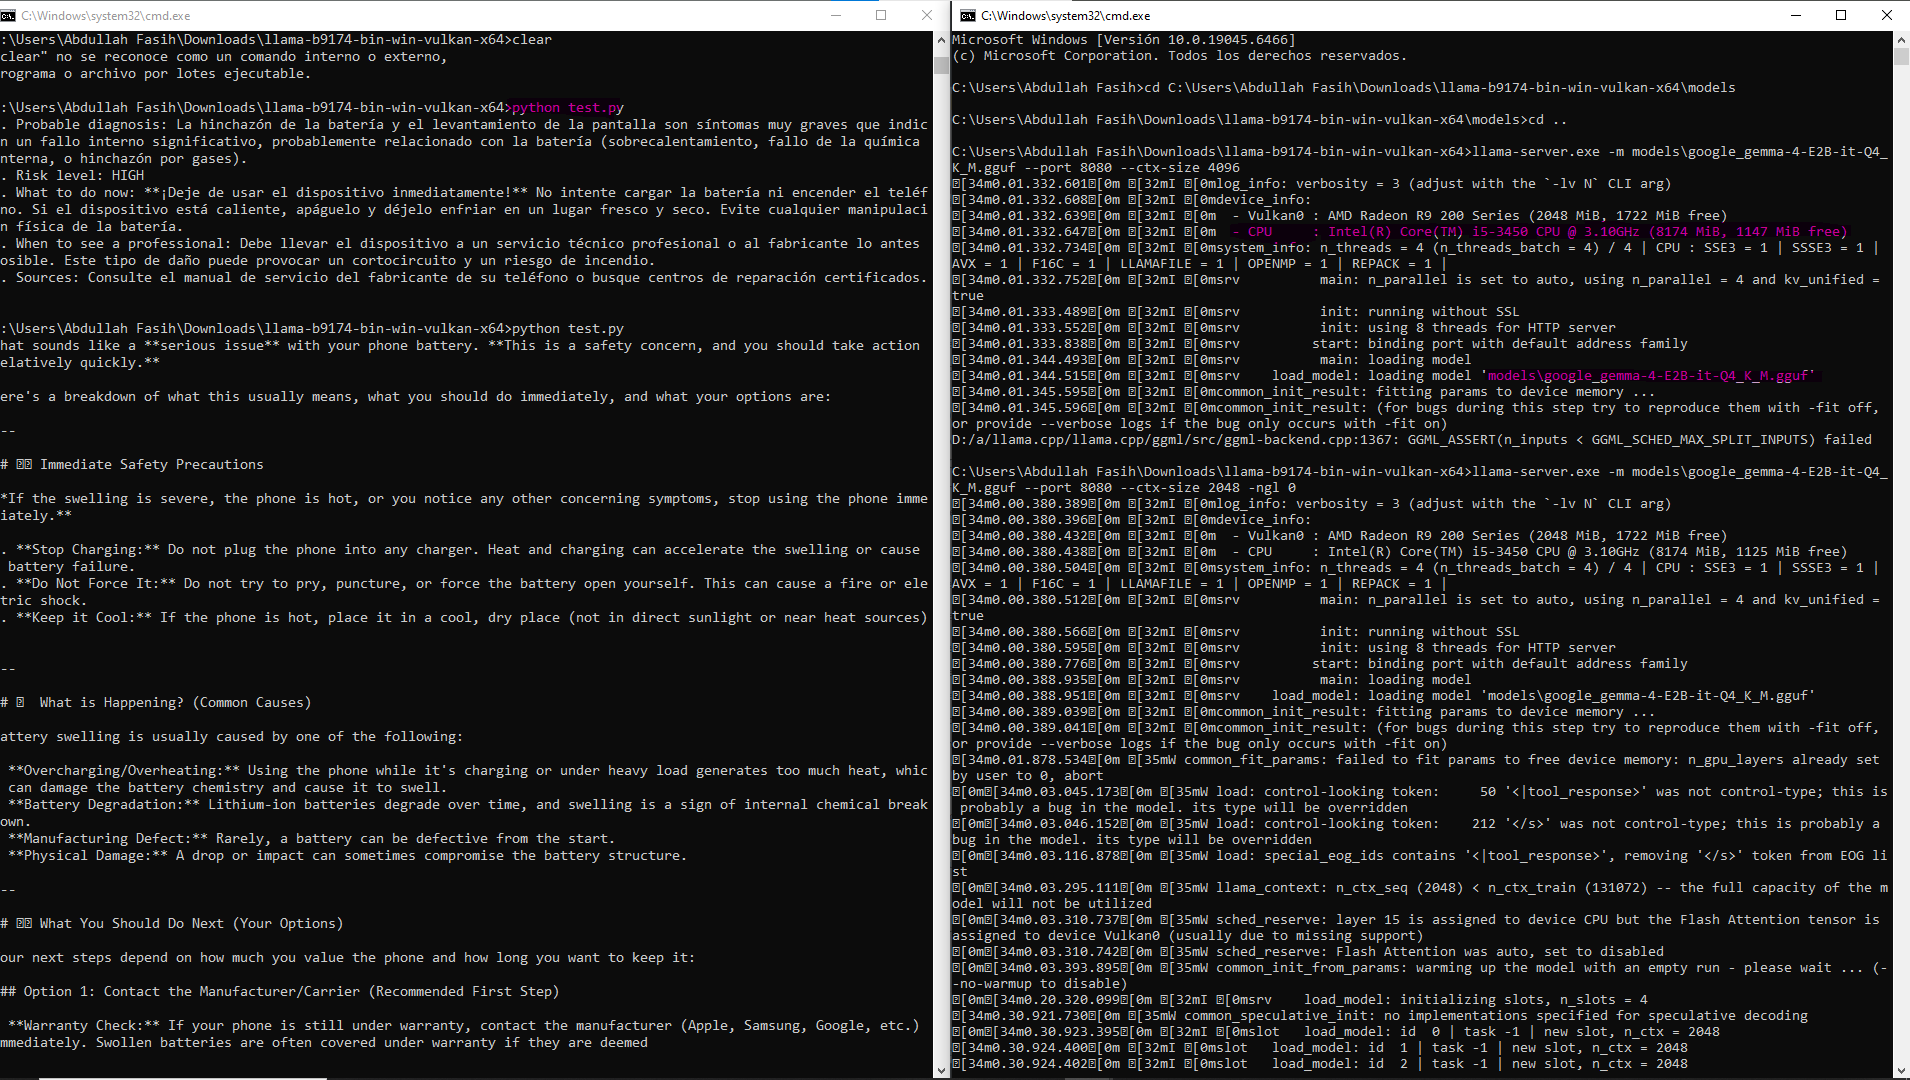
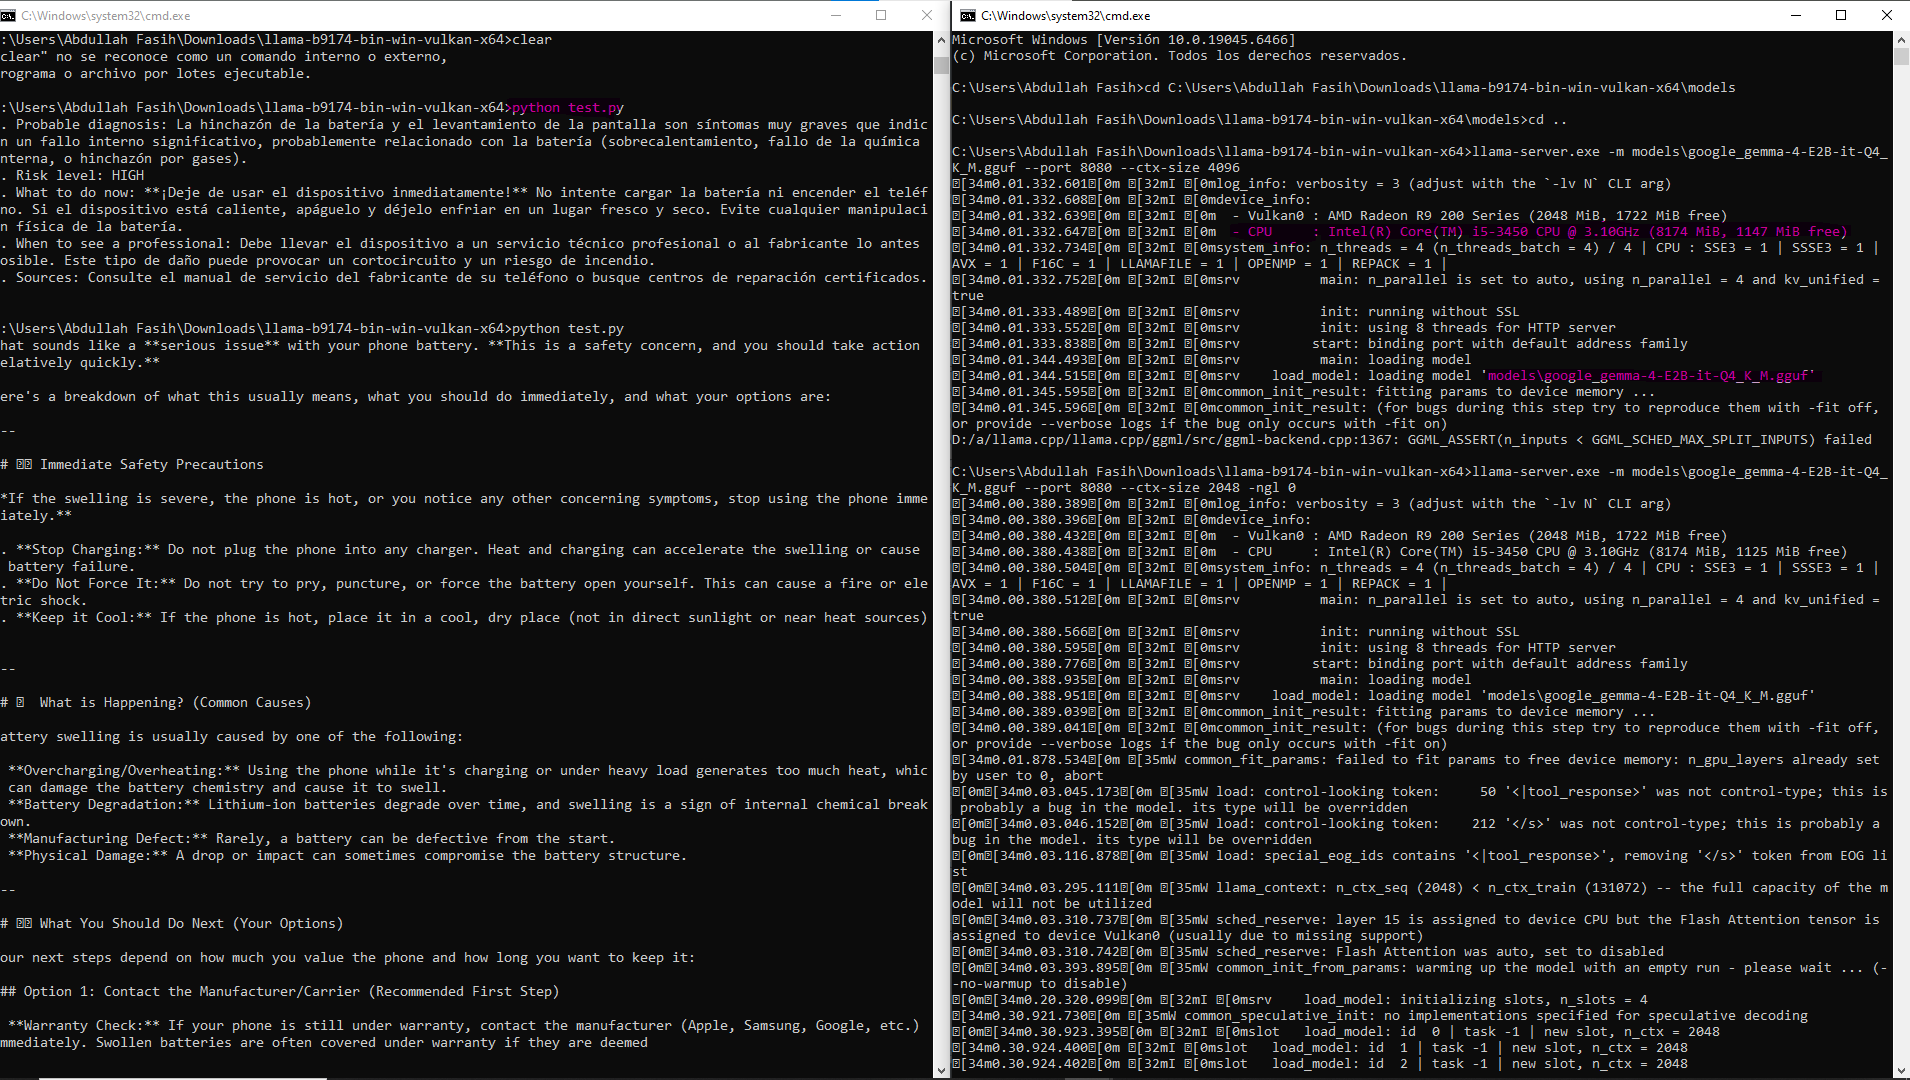

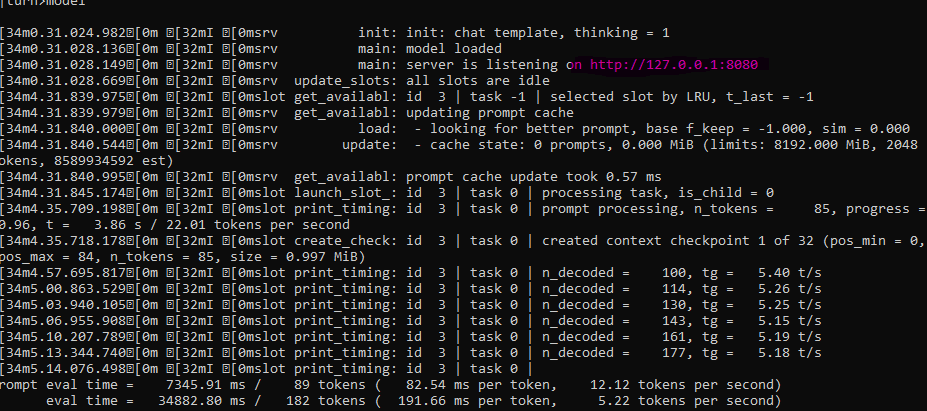